In [20]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import json
import copy

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from utils.evaluator import Evaluator
from models.baseline_models import LSTMModel, BiLSTMModel, GRUModel
from models.custom_models import MGSSMsModel, ExtendedMGSSMsModel

In [ ]:
train_loader, val_loader, test_loader, scaler = load_and_prepare_time_series_data(
    filepath_or_url = "https://zenodo.org/records/17109911/files/system_2023.csv",
    target_column=['metropolitan_demand'],
    date_column="time",
    seq_length=14,
    batch_size=64,
    train_split=0.8,
    fill_missing=True)

Fetching data from: https://zenodo.org/records/17109911/files/system_2023.csv


In [22]:
# Setup model configurations
model_config_dict = {
    "Baseline LSTM": LSTMModel(input_size=1, hidden_size=16, num_layers=1, output_size=1),
    "Baseline BiLSTM": BiLSTMModel(input_size=1, hidden_size=256, num_layers=1, output_size=1),
    "Baseline GRU": GRUModel(input_size=1, hidden_size=16, num_layers=1, output_size=1),
    "MGSSMs": MGSSMsModel(input_size=1, hidden_size=128, num_layers=1, output_size=1, gate_size=32),
    "ExtendedMGSSMs_p2": ExtendedMGSSMsModel(input_size=1, hidden_size=256, num_layers=1, output_size=1, gate_size=32, p=2),
    "ExtendedMGSSMs_p3": ExtendedMGSSMsModel(input_size=1, hidden_size=256, num_layers=1, output_size=1, gate_size=32, p=5)
}

In [24]:
model_trained = []
for name, model in model_config_dict.items():
    print(f"Training model: {name}")
    trainer = Trainer(
        model=model,
        criterion=nn.MSELoss(),
        optimizer=optim.Adam(model.parameters(), lr=0.001),
        device="cpu"
    )
    train_loader = train_loader
    val_loader = val_loader
    trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000, patience=50, label='elec2023')

Training model: Baseline LSTM
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 582 epochs.
Training complete! Best validation loss: 0.0004. Model saved to checkpoints/best_LSTMModel_elec2023.pth
Training model: Baseline BiLSTM
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [17]:
def plot_predictions(model, test_loader, scaler):
    model.eval()
    
    actuals = []
    predictions = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            preds = model(batch_x)
            actuals.extend(batch_y.cpu().numpy().flatten())
            predictions.extend(preds.cpu().numpy().flatten())

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
            
    # Plotting the validation data
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual metropolitan_demand", color="blue")
    plt.plot(predictions, label="Model Predictions", color="red", linestyle="--")
    plt.title(f"{model.__class__.__name__} Forecasting on COVID-19 Open Data")
    plt.xlabel("hours")
    plt.ylabel("metropolitan_demand")
    plt.xlim(200, 300)
    plt.legend()
    plt.grid(True)
    plt.show()

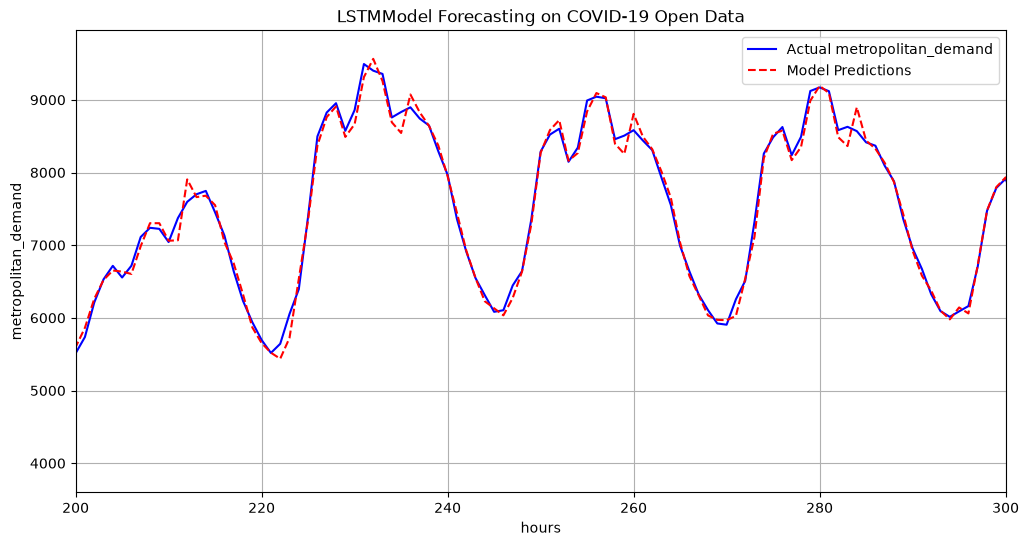

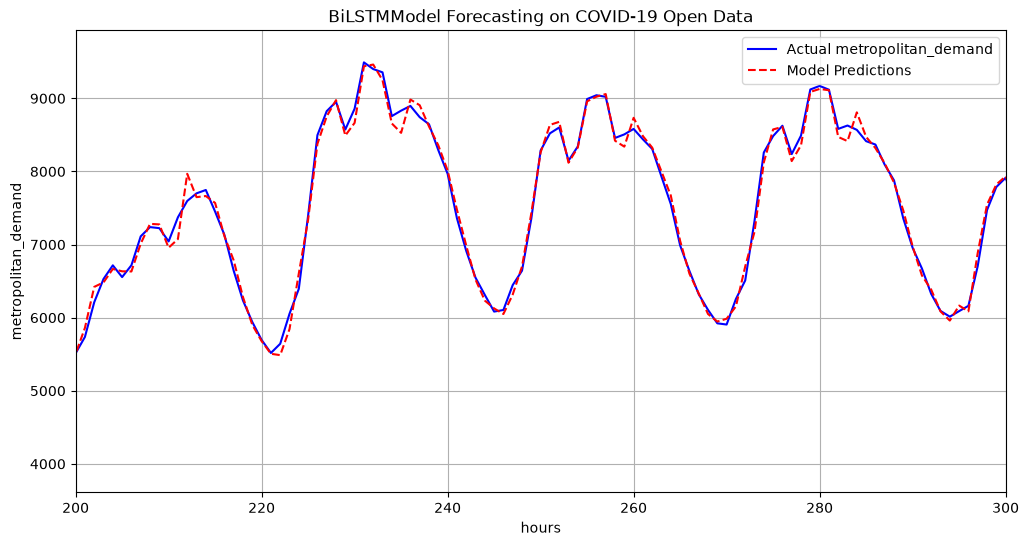

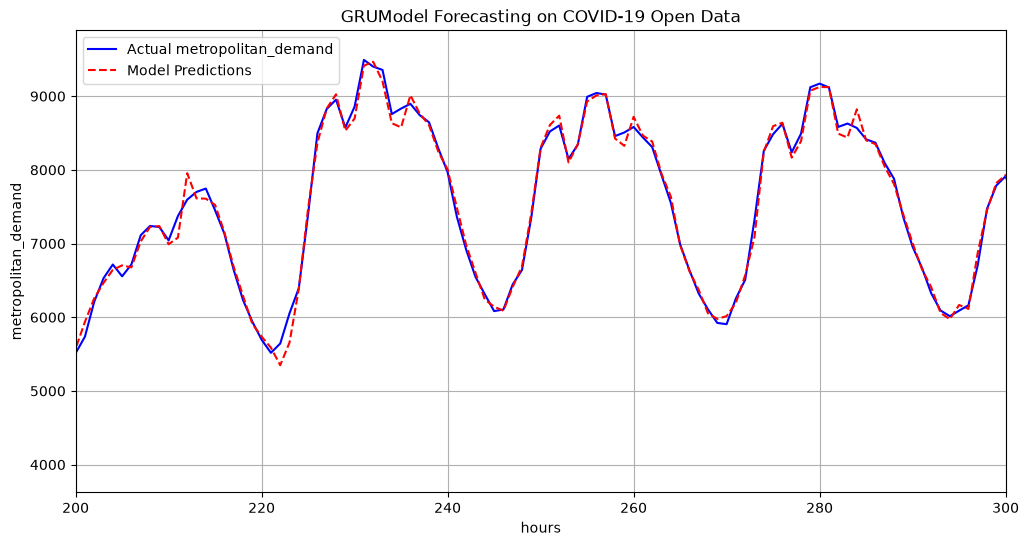

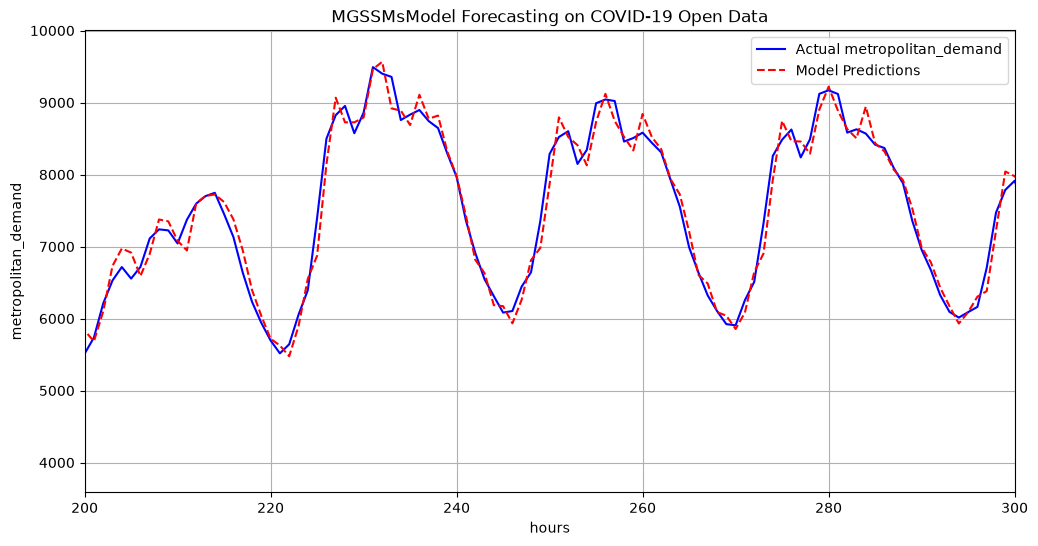

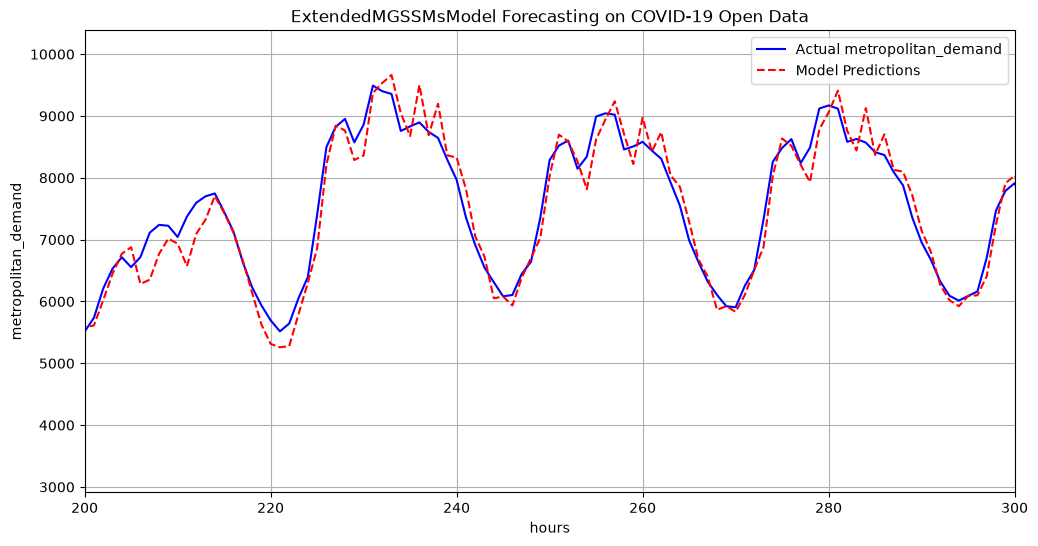

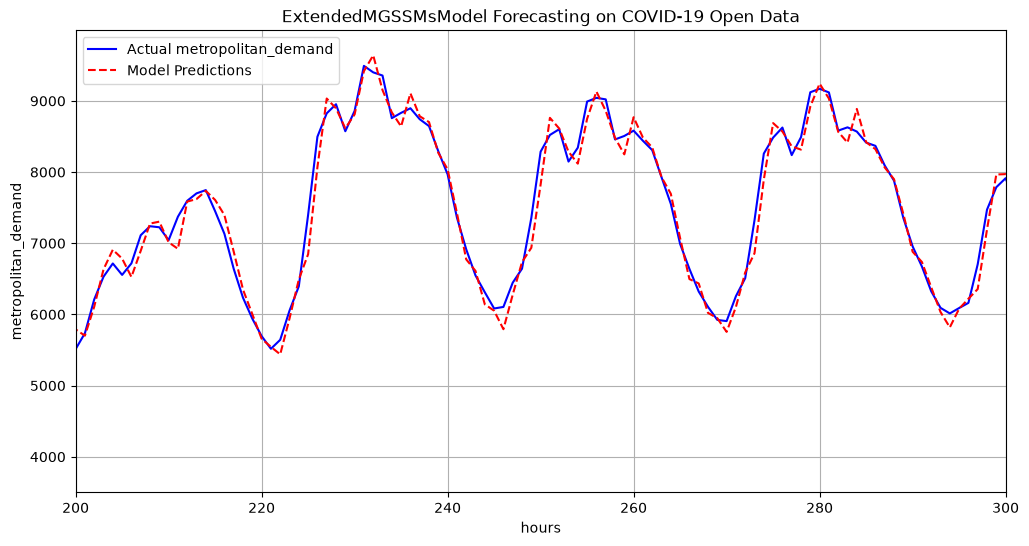

In [18]:
for model_config in model_config_dict.values():
    # analyze the model from the checkpoint
    model_config.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_elec2023.pth"))
    plot_predictions(model_config, test_loader, scaler)

In [19]:
test_loader_dist = {'2023': test_loader}
scaler_dist = {'2023': scaler}
trained_model_dict = {}
# loading the checkpointed models
for model_name, model_config in model_config_dict.items():
    # analyze the model from the checkpoint
        specific_model = copy.deepcopy(model_config)
        specific_model.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_elec2023.pth"))
        trained_model_dict[model_name] = specific_model

evaluator = Evaluator()
evaluator.compare_models(trained_model_dict, test_loader_dist['2023'], scaler_dist['2023'])

Evaluating model: Baseline LSTM...
Evaluating model: Baseline BiLSTM...
Evaluating model: Baseline GRU...
Evaluating model: MGSSMs...
Evaluating model: ExtendedMGSSMs_p2...
Evaluating model: ExtendedMGSSMs_p5...


,MSE,RMSE,MAE,R2,MAPE,Adjusted MAPE
Model,,,,,,
Baseline LSTM,11906.982422,109.119120,79.231560,0.994032,0.012107,None
Baseline BiLSTM,11676.478516,108.057755,78.944366,0.994148,0.012313,None
Baseline GRU,11709.847656,108.212049,78.146461,0.994131,0.012126,None
MGSSMs,44688.453125,211.396436,172.012619,0.977603,0.025867,None
ExtendedMGSSMs_p2,116345.726562,341.094894,265.028900,0.941689,0.041562,None
ExtendedMGSSMs_p5,33470.757812,182.950151,141.312057,0.983225,0.021186,None
